In [1]:
pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 134.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [2]:
from roboflow import Roboflow

rf = Roboflow(api_key="wDkXkq1p6HgQkEouDCMQ")  # free at roboflow.com
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
dataset = project.version(4).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to License-Plate-Recognition-4 in yolov8:: 100%|██████████| 48488/48488 [00:06<00:00, 8034.68it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")  # start from pretrained nano; use 's' or 'm' for more accuracy

model.train(
    data="/content/License-Plate-Recognition-4/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="lp_detector",
    patience=10,       # early stopping
    augment=True,
)

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-4/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=lp_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pat

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a1561e00b60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [5]:
metrics = model.val()
print(metrics.box.map)    # mAP@0.5:0.95
print(metrics.box.map50)  # mAP@0.5

Ultralytics 8.4.34 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 892.2±264.9 MB/s, size: 34.5 KB)
val: Scanning /content/License-Plate-Recognition-4/valid/labels.cache... 2046 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2046/2046 504.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 128/128 7.7it/s 16.5s
                   all       2046       2132      0.985      0.959      0.985      0.709
Speed: 0.8ms preprocess, 3.6ms inference, 0.0ms loss, 0.9ms postprocess per image
Results saved to /content/runs/detect/val
0.7086848709452677
0.9850401580228305


In [7]:
model = YOLO("runs/detect/lp_detector/weights/best.pt")

results = model.predict(
    source="/content/Plate test.jpg",  # or video path, or 0 for webcam
    conf=0.4,
    save=True,
    show=True
)

# Get bounding boxes
for r in results:
    for box in r.boxes:
        print(box.xyxy, box.conf)  # coords + confidence


image 1/1 /content/Plate test.jpg: 512x640 1 License_Plate, 47.2ms
Speed: 3.7ms preprocess, 47.2ms inference, 1.8ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /content/runs/detect/predict
tensor([[ 65.0695, 179.1061, 132.1945, 208.8899]], device='cuda:0') tensor([0.8013], device='cuda:0')



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1019 /content/License-Plate-Recognition-4/test/images/0002a5b67e5f0909_jpg.rf.07ca41e79eb878b14032f650f34d0967.jpg: 640x640 2 License_Plates, 7.2ms
image 2/1019 /content/License-Plate-Recognition-4/test/images/000812dcf304a8e7_jpg.rf.559f904bc045f68ee947796a1b561d8f.jpg: 640x640 1 License_Plate, 7.2ms
image 3/1019 /content/License-Plate-Recognition-4/test/images/0010f4c10f7ab07e_jpg.rf.92344aa620e23aacc490273e32343595.jpg: 640x640 1 License_Plate

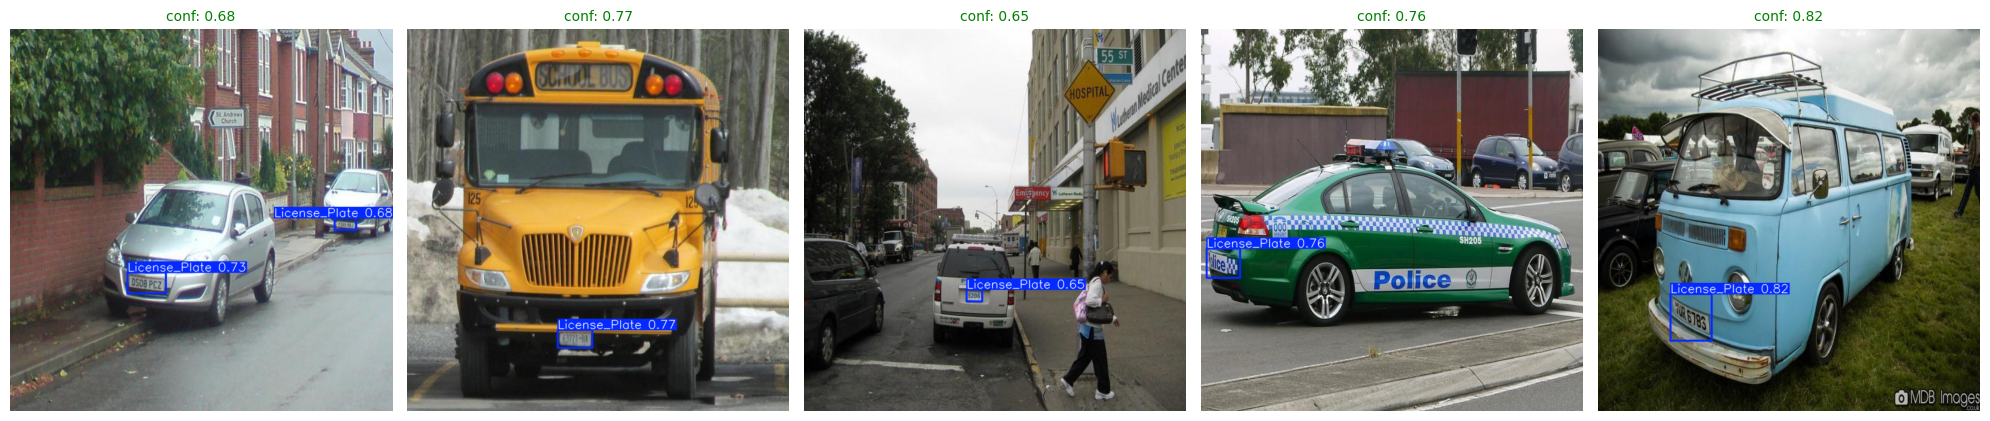

✅ 1019 images predicted


In [15]:
import cv2
import matplotlib.pyplot as plt
from google.colab import files
from ultralytics import YOLO

# Load your trained model
model = YOLO("/content/runs/detect/lp_detector/weights/best.pt")

# Run prediction on a test image from the dataset
results = model.predict(
    source="/content/License-Plate-Recognition-4/test/images",  # whole test folder
    conf=0.4,
    save=True,                # saves annotated images to runs/detect/predict/
    show=False,
)

# ── Visualize the first 5 results inline ──────────────────────────────
fig, axes = plt.subplots(1, min(5, len(results)), figsize=(20, 6))
if len(results) == 1:
    axes = [axes]

for i, r in enumerate(results[:5]):
    img = r.plot()                        # BGR numpy array with boxes drawn
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[i].imshow(img_rgb)
    axes[i].axis("off")

    # Print detected plate info below each image
    for box in r.boxes:
        conf = float(box.conf[0])
        axes[i].set_title(f"conf: {conf:.2f}", fontsize=10, color="green")

plt.tight_layout()
plt.savefig("/content/predictions_preview.jpg", dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ {len(results)} images predicted")

In [16]:
# Option A — download the preview grid (all 5 in one image)
files.download("/content/predictions_preview.jpg")

# Option B — download ALL annotated test images as a zip
import shutil
shutil.make_archive("/content/all_predictions", "zip",
                    "/content/runs/detect/predict")
files.download("/content/all_predictions.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>